In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import mahalanobis

In [2]:
# Load your real dataset
df = pd.read_csv("Life_Expectancy_Selected_Features.csv")

# Separate features and target
X = df.drop(columns=["Life expectancy"]).values
y = df["Life expectancy"].values

# Standardize features
X = StandardScaler().fit_transform(X)
y = (y - np.mean(y)) / np.std(y)

In [3]:
# Save original weights using OLS for ground truth approximation
true_weights_real = np.linalg.pinv(X) @ y
true_weights_real

array([-1.12457973,  1.08001428, -0.27241813, -0.24655618,  0.27532898,
        0.15368311,  0.08645114,  0.11633591,  0.06817904])

In [4]:
# Corrupt the data
np.random.seed(42)
n = X.shape[0]
corruption_fraction = 0.3
num_corrupted = int(corruption_fraction * n)
corrupted_indices = np.random.choice(n, num_corrupted, replace=False)

X_corrupted = X.copy()
y_corrupted = y.copy()

X_corrupted[corrupted_indices] += np.random.uniform(-5, 5, size=X.shape[1])
y_corrupted[corrupted_indices] += np.random.uniform(-5, 5, size=num_corrupted)

In [5]:
# Joint outlier score: residual + λ * feature deviation
def compute_joint_outlier_score(X, y, w, lambda_):
    residuals = np.abs(y - X @ w)
    feature_deviation = np.sum((X - np.mean(X, axis=0))**2, axis=1)
    return residuals + lambda_ * feature_deviation

# Hybrid thresholding
def hybrid_thresholding(X, y, w, beta, lambda_):
    scores = compute_joint_outlier_score(X, y, w, lambda_)
    k = int((1 - beta) * len(scores))
    return np.argsort(scores)[:k]

# Fully corrective step
def update_weights(X, y, active_set):
    X_active = X[active_set]
    y_active = y[active_set]
    return np.linalg.pinv(X_active) @ y_active

# Loss function: restricted least squares
def rslr_loss(X, y, w, active_set):
    return np.mean((y[active_set] - X[active_set] @ w) ** 2)

In [6]:
def torrent_fc_joint(X, y, beta, tol, max_iter, lambda_):
    n, p = X.shape
    w = np.zeros(p)
    active_set = np.arange(n)
    losses, active_set_stability = [], []

    for t in range(max_iter):
        w_new = update_weights(X, y, active_set)
        new_active_set = hybrid_thresholding(X, y, w_new, beta, lambda_)
        losses.append(rslr_loss(X, y, w_new, new_active_set))

        stability = len(np.intersect1d(active_set, new_active_set)) / len(active_set)
        active_set_stability.append(stability)

        if np.linalg.norm(w_new - w) < tol:
            break
        w = w_new
        active_set = new_active_set

    return w, losses, active_set_stability

In [7]:
# HYB version
def torrent_hyb_joint(X, y, beta, tol, max_iter, lambda_, eta, delta_switch):
    n, p = X.shape
    w = np.zeros(p)
    active_set = np.arange(n)
    losses, active_set_stability = [], []

    for t in range(max_iter):
        new_active_set = hybrid_thresholding(X, y, w, beta, lambda_)
        stability = len(np.intersect1d(active_set, new_active_set)) / len(active_set)
        active_set_stability.append(stability)

        if 1 - stability > delta_switch:
            # Use GD step
            X_active = X[new_active_set]
            y_active = y[new_active_set]
            grad = X_active.T @ (X_active @ w - y_active)
            w_new = w - eta * grad
        else:
            # Use FC step
            w_new = update_weights(X, y, new_active_set)

        losses.append(rslr_loss(X, y, w_new, new_active_set))

        if np.linalg.norm(w_new - w) < tol:
            break
        w = w_new
        active_set = new_active_set

    return w, losses, active_set_stability

In [8]:
beta = 0.3
lambda_ = 0.1
tol = 1e-8
max_iter = 1000
eta = 0.001
delta_switch = 0.1

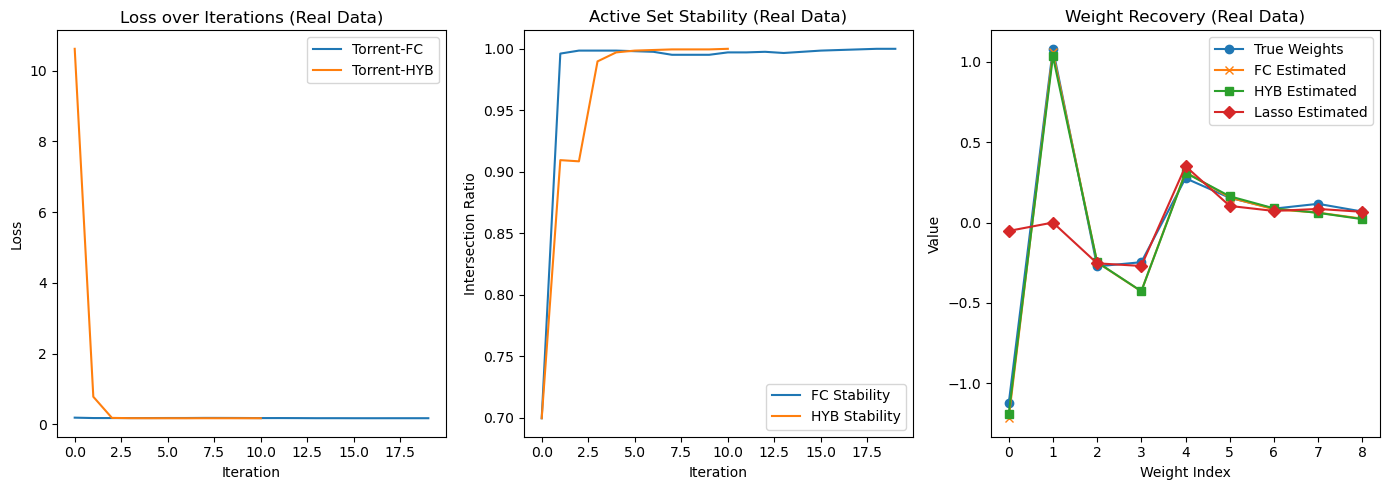

{'MSE_FC_real': 0.005419854925649198,
 'Recovery_Error_FC_real': 0.22085899196284217,
 'MSE_HYB_real': 0.005156954341071875,
 'Recovery_Error_HYB_real': 0.21543581194789058}

In [9]:
# Run Torrent-FC and HYB on real corrupted data
w_fc_real, losses_fc_real, stability_fc_real = torrent_fc_joint(X_corrupted, y_corrupted, beta, tol, max_iter, lambda_)
w_hyb_real, losses_hyb_real, stability_hyb_real = torrent_hyb_joint(X_corrupted, y_corrupted, beta, tol, max_iter, lambda_, eta, delta_switch)

# Evaluation
mse_fc_real = mean_squared_error(true_weights_real, w_fc_real)
mse_hyb_real = mean_squared_error(true_weights_real, w_hyb_real)
recovery_error_fc_real = np.linalg.norm(w_fc_real - true_weights_real)
recovery_error_hyb_real = np.linalg.norm(w_hyb_real - true_weights_real)


lasso = Lasso(alpha=0.01) 
lasso.fit(X_corrupted, y_corrupted)
w_lasso = lasso.coef_

# Plotting
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(losses_fc_real, label="Torrent-FC")
plt.plot(losses_hyb_real, label="Torrent-HYB")
plt.title("Loss over Iterations (Real Data)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(stability_fc_real, label="FC Stability")
plt.plot(stability_hyb_real, label="HYB Stability")
plt.title("Active Set Stability (Real Data)")
plt.xlabel("Iteration")
plt.ylabel("Intersection Ratio")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(true_weights_real, label="True Weights", marker='o')
plt.plot(w_fc_real, label="FC Estimated", marker='x')
plt.plot(w_hyb_real, label="HYB Estimated", marker='s')
plt.plot(w_lasso, label="Lasso Estimated", marker='D')
plt.title("Weight Recovery (Real Data)")
plt.xlabel("Weight Index")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

{
    "MSE_FC_real": mse_fc_real,
    "Recovery_Error_FC_real": recovery_error_fc_real,
    "MSE_HYB_real": mse_hyb_real,
    "Recovery_Error_HYB_real": recovery_error_hyb_real
}

In [10]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=[0.01, 0.05, 0.1, 0.2, 0.5, 1.0], cv=5)
lasso_cv.fit(X_corrupted, y_corrupted)

print("Best alpha:", lasso_cv.alpha_)
print("MSE:", mean_squared_error(true_weights_real, lasso_cv.coef_))

Best alpha: 0.05
MSE: 0.2657115354456494


When corruption level = 0.1
When corruption level = 0.3
When corruption level = 0.5
When corruption level = 0.7
When corruption level = 0.8


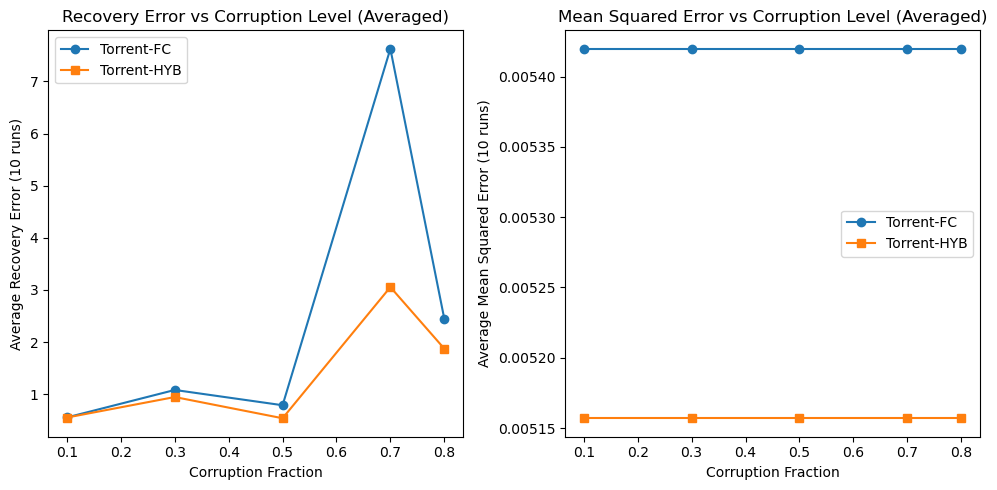

In [14]:
corruption_levels = [0.1, 0.3, 0.5, 0.7, 0.8]
recovery_errors_fc = []
recovery_errors_hyb = []
mean_squared_errors_fc = []
mean_squared_errors_hyb = []

# Fixed Torrent settings
beta = 0.5
lambda_ = 0.1
tol = 1e-6
max_iter = 1000
eta = 0.001
delta_switch = 0.1
runs_per_level = 10

for frac in corruption_levels:
    errors_fc = []
    errors_hyb = []
    mse_fc = []
    mse_hyb = []
    print(f"When corruption level = {frac}")

    for run in range(runs_per_level):
        np.random.seed(42)  
        num_corrupted = int(frac * X.shape[0])
        corrupted_indices = np.random.choice(X.shape[0], num_corrupted, replace=False)
        X_corrupted = X.copy()
        y_corrupted = y.copy()
        X_corrupted[corrupted_indices] += np.random.uniform(-5, 5, size=X.shape[1])
        y_corrupted[corrupted_indices] += np.random.uniform(-5, 5, size=num_corrupted)

        # Run FC and HYB
        w_fc, _, _ = torrent_fc_joint(X_corrupted, y_corrupted, beta, tol, max_iter, lambda_)
        w_hyb, _, _ = torrent_hyb_joint(X_corrupted, y_corrupted, beta, tol, max_iter, lambda_, eta, delta_switch)

        # Recovery error
        err_fc = np.linalg.norm(w_fc - true_weights_real)
        err_hyb = np.linalg.norm(w_hyb - true_weights_real)

        mse_fc_run = mean_squared_error(true_weights_real, w_fc_real)
        mse_hyb_run = mean_squared_error(true_weights_real, w_hyb_real)

        errors_fc.append(err_fc)
        errors_hyb.append(err_hyb)
        mse_fc.append(mse_fc_run)
        mse_hyb.append(mse_hyb_run)

    # Average across runs
    recovery_errors_fc.append(np.mean(errors_fc))
    recovery_errors_hyb.append(np.mean(errors_hyb))
    mean_squared_errors_fc.append(np.mean(mse_fc))
    mean_squared_errors_hyb.append(np.mean(mse_hyb))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(corruption_levels, recovery_errors_fc, marker='o', label='Torrent-FC')
plt.plot(corruption_levels, recovery_errors_hyb, marker='s', label='Torrent-HYB')
plt.xlabel("Corruption Fraction")
plt.ylabel("Average Recovery Error (10 runs)")
plt.title("Recovery Error vs Corruption Level (Averaged)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(corruption_levels, mean_squared_errors_fc, marker='o', label='Torrent-FC')
plt.plot(corruption_levels, mean_squared_errors_hyb, marker='s', label='Torrent-HYB')
plt.xlabel("Corruption Fraction")
plt.ylabel("Average Mean Squared Error (10 runs)")
plt.title("Mean Squared Error vs Corruption Level (Averaged)")
plt.legend()

plt.tight_layout()
plt.show()

Running for lambda = 0.01
Running for lambda = 0.05
Running for lambda = 0.1
Running for lambda = 0.5
Running for lambda = 1.0


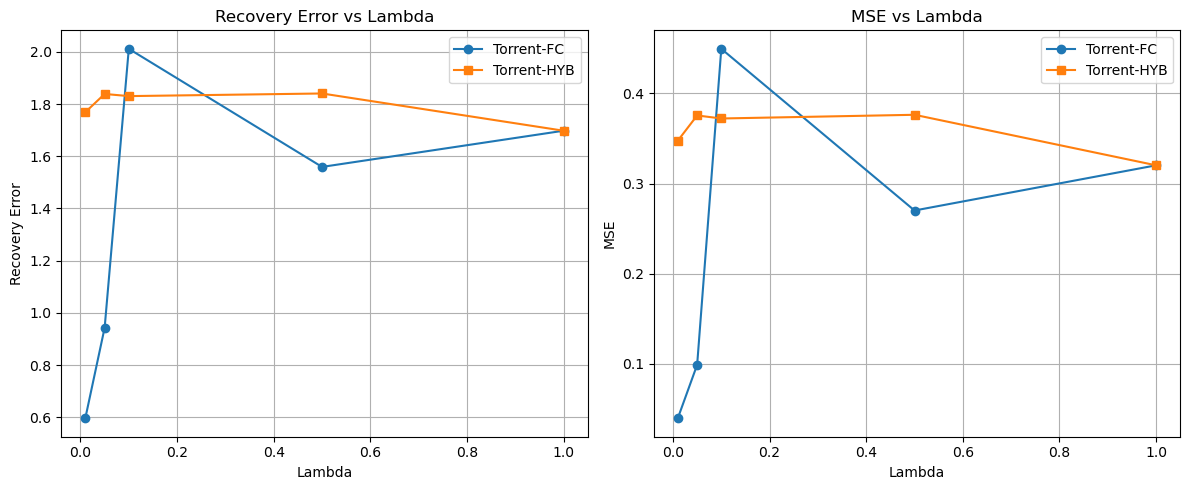

In [12]:
lambda_vals = [0.01, 0.05, 0.1, 0.5, 1.0]
recovery_errors_fc = []
recovery_errors_hyb = []
mse_fc_list = []
mse_hyb_list = []

# Fixed Torrent settings
beta = 0.3
tol = 1e-6
max_iter = 1000
eta = 0.001
delta_switch = 0.1

for lambda_ in lambda_vals:
    print(f"Running for lambda = {lambda_}")

    # Run FC
    w_fc, _, _ = torrent_fc_joint(X_corrupted, y_corrupted, beta, tol, max_iter, lambda_)
    mse_fc = mean_squared_error(true_weights_real, w_fc)
    recovery_fc = np.linalg.norm(w_fc - true_weights_real)

    # Run HYB
    w_hyb, _, _ = torrent_hyb_joint(X_corrupted, y_corrupted, beta, tol, max_iter, lambda_, eta, delta_switch)
    mse_hyb = mean_squared_error(true_weights_real, w_hyb)
    recovery_hyb = np.linalg.norm(w_hyb - true_weights_real)

    # Store results
    mse_fc_list.append(mse_fc)
    mse_hyb_list.append(mse_hyb)
    recovery_errors_fc.append(recovery_fc)
    recovery_errors_hyb.append(recovery_hyb)

import matplotlib.pyplot as plt

# Plot Recovery Error
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lambda_vals, recovery_errors_fc, marker='o', label='Torrent-FC')
plt.plot(lambda_vals, recovery_errors_hyb, marker='s', label='Torrent-HYB')
plt.xlabel("Lambda")
plt.ylabel("Recovery Error")
plt.title("Recovery Error vs Lambda")
plt.grid(True)
plt.legend()

# Plot MSE
plt.subplot(1, 2, 2)
plt.plot(lambda_vals, mse_fc_list, marker='o', label='Torrent-FC')
plt.plot(lambda_vals, mse_hyb_list, marker='s', label='Torrent-HYB')
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("MSE vs Lambda")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()